# Singapore Government Procurement (GeBIZ) — Audit Analysis

**Question:** using publicly disclosed GeBIZ award data, can we identify supplier concentration, amount-threshold clustering, and Benford's-law deviations that would be worth an auditor's attention?

**Data source:** [data.gov.sg — Government Procurement via GeBIZ](https://data.gov.sg/datasets/d_acde1106003906a75c3fa052592f2fcb/view) (Ministry of Finance), Open Data Licence.

This notebook reproduces the four analyses in the project brief. Data-quality decisions (why each cleaning rule exists) are documented in [`../notes.md`](../notes.md) — this notebook focuses on running the analysis and interpreting results, not re-deriving those decisions.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from cleaning import clean_pipeline
from analysis import (
    concentration_by_group, threshold_window_counts, benford_test, BENFORD_EXPECTED,
    top_suppliers, yearly_trend, agency_year_pivot,
)
from plotting import set_style
set_style()

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Load and clean

See `notes.md` for the full data-quality investigation. Summary of what `clean_pipeline` does:
- drops 639 "Awarded to No Suppliers" rows (no real award happened)
- normalizes supplier name punctuation/case/suffix spelling (conservatively — verified it only merges 7 groups, all confirmed true duplicates)
- parses `award_date` and derives Singapore fiscal year (Apr–Mar)

In [2]:
df_raw = pd.read_csv('../data/raw/gebiz_procurement.csv', low_memory=False)
df = clean_pipeline(df_raw)

print(f'raw rows: {len(df_raw):,} -> cleaned rows: {len(df):,}')
print(f'raw distinct suppliers: {df_raw["supplier_name"].nunique():,} -> normalized: {df["supplier_name"].nunique():,}')
df.head(3)

raw rows: 18,464 -> cleaned rows: 17,825
raw distinct suppliers: 6,152 -> normalized: 6,144


,tender_no,tender_description,agency,award_date,tender_detail_status,supplier_name,awarded_amt,supplier_name_raw,fiscal_year
0,ACR000ETT21000001,"DESIGN, DEVELOPMENT, CUSTOMIZATION, DELIVERY, ...",Accounting And Corporate Regulatory Authority,2021-09-06,Awarded to Suppliers,ALPHA ZETTA PTE LTD,2321600.0,ALPHA ZETTA PTE. LTD.,FY2021
1,ACR000ETT21000003,"SUPPLY, DELIVERY, INSTALLATION, TESTING, COMMI...",Accounting And Corporate Regulatory Authority,2022-04-14,Awarded to Suppliers,ACCENTURE SG SERVICES PTE LTD,108555723.0,ACCENTURE SG SERVICES PTE. LTD.,FY2022
2,ACR000ETT21000004,INVITATION TO TENDER FOR THE APPLICATION SOFTW...,Accounting And Corporate Regulatory Authority,2022-04-13,Awarded to Suppliers,CRIMSONLOGIC PTE LTD,4503450.0,CRIMSONLOGIC PTE LTD,FY2022


## 2. Supplier concentration (HHI / CR4)

**Metric choice:** I compute both HHI (sum of squared market shares, 0–10,000) and CR4 (combined share of the top 4 suppliers) — they usually agree, but CR4 is easier to explain to a non-technical stakeholder ("4 firms take X% of spend") while HHI is the more standard antitrust/regulatory benchmark. I report both rather than picking one.

**Unit choice:** concentration is computed **by amount**, not by award count. A supplier that wins one $500M contract and a supplier that wins fifty $10k contracts have very different market power; amount-weighting captures that, count-weighting doesn't. I compute both below to show they can disagree.

**Grouping:** concentration only means something *within* a comparable procurement pool. A whole-of-government HHI conflates a school buying stationery with LTA building an MRT tunnel — so I compute it per agency, not as one national number (confirmed below: the national number is uninformatively close to zero).

In [3]:
df['_all'] = 'Whole of government'
print('Whole-of-government concentration (why a single national number is not useful):')
display(concentration_by_group(df, ['_all'], min_awards=1))

print('\nTop 12 agencies by amount-weighted HHI (min. 10 awards, so single-contract agencies do not dominate the list):')
conc_amount = concentration_by_group(df, ['agency'], min_awards=10)
display(conc_amount.head(12))

df['count1'] = 1
conc_count = concentration_by_group(df, ['agency'], value_col='count1', min_awards=10)
print('\nSame agencies, ranked by COUNT-weighted HHI instead — notice the ranking changes:')
display(conc_count.head(12))

Whole-of-government concentration (why a single national number is not useful):


,_all,hhi,n_suppliers,total,cr4,n_awards
0,Whole of government,69.030525,6144,1.238219e+11,9.080031,17825



Top 12 agencies by amount-weighted HHI (min. 10 awards, so single-contract agencies do not dominate the list):


,agency,hhi,n_suppliers,total,cr4,n_awards
0,Science Centre Board,8314.413739,64,6.323756e+08,95.017787,101
1,Accounting And Corporate Regulatory Authority,8298.080006,10,1.193574e+08,98.208058,11
2,Ministry of Trade & Industry-Ministry Headquarter,8161.330490,28,4.030053e+08,96.130631,29
3,Council for Estate Agencies,7099.052043,20,1.997556e+07,88.660143,29
4,Ministry of National Development-Ministry Head...,6697.771459,34,5.324857e+08,96.393597,37
5,Inland Revenue Authority of Singapore,6331.488682,40,2.269575e+08,90.372851,48
6,Ministry of Finance - Singapore Customs,5429.995862,49,2.628220e+08,86.477903,60
7,Singapore Sports Council (Sport Singapore),5304.860966,208,1.409106e+09,84.696041,251
8,Judiciary-State Courts,5225.109973,10,5.962676e+07,86.150545,12
9,Singapore Medical Council,5120.960179,17,2.708694e+06,93.958675,41



Same agencies, ranked by COUNT-weighted HHI instead — notice the ranking changes:


,agency,hhi,n_suppliers,total,cr4,n_awards
0,Istana,1600.000000,7,10,70.000000,10
1,Ministry of Trade & Industry-Department of Sta...,1280.276817,11,17,58.823529,17
2,Prime Minister's Office-Ministry Headquarter,1220.850480,17,27,51.851852,27
3,Prime Minister's Office-Elections Department,1200.000000,9,10,50.000000,10
4,Judiciary-State Courts,1111.111111,10,12,50.000000,12
5,Accounting And Corporate Regulatory Authority,1074.380165,10,11,45.454545,11
6,Ministry of Manpower - Work Pass Division,1000.000000,10,10,40.000000,10
7,National Environment Agency - ENV19,1000.000000,10,10,40.000000,10
8,Singapore Chinese Girls' School,918.367347,12,14,42.857143,14
9,"School of Science and Technology, Singapore",914.127424,15,19,42.105263,19


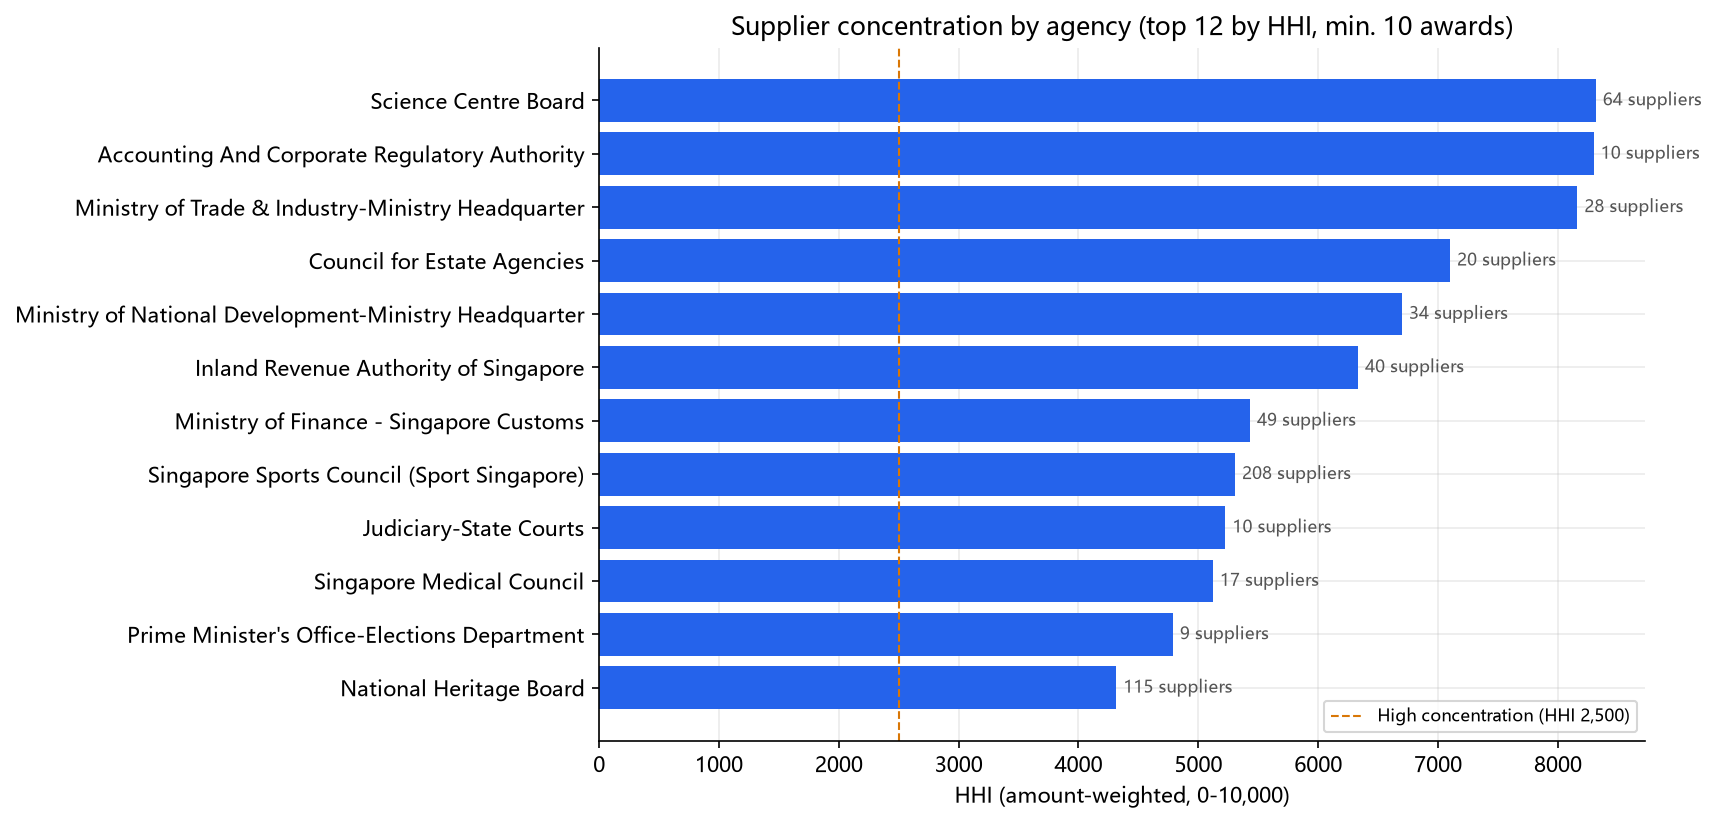

In [4]:
display(Image('../outputs/figures/concentration_by_agency.png'))

### Interpretation

- **Amount-weighted concentration is high (HHI 4,000–8,300+) for several agencies even when they have 30–200+ distinct suppliers** (e.g. Science Centre Board: 64 suppliers, HHI 8,314; Singapore Sports Council: 208 suppliers, HHI 5,305). This is not a sign of a captured or thin supplier pool — it means one or two very large contracts dominate the agency's *dollar* spend, while many smaller suppliers share the rest. Amount- and count-weighted HHI diverge exactly where this pattern holds.
- **The count-weighted top list looks completely different** (Istana, PMO divisions, State Courts) — agencies with genuinely few, tightly-scoped suppliers, which for some of these (e.g. Istana, a security-sensitive site) is a reasonable procurement pattern, not necessarily a red flag.
- **A single whole-of-government HHI is close to zero and not meaningful** — it mixes thousands of unrelated procurement categories. Concentration should always be read at the agency (or ideally category) level, never as one national figure.
- I am **not** claiming any specific agency's concentration is improper — high HHI for a specialized government agency buying specialized equipment/services can be entirely legitimate (limited qualified suppliers). This analysis flags where to *look closer* (e.g. checking whether the dominant contract was competitively tendered), not a verdict.

## 3. Amount-threshold clustering

**Business research (not in the raw data):** Singapore's public procurement rules (Ministry of Finance) define three tiers by estimated value:
- **Small Value Purchase**: up to **S$6,000** — informal, minimal process
- **Quotation**: **S$6,000 – S$90,000** — invited quotations via GeBIZ
- **Open Tender**: **above S$90,000** — full public tender

(Source: [MOF — Procurement processes](https://www.mof.gov.sg/policies/government-procurement/procurement-processes/).) An award amount that clusters just *below* S$90,000 rather than being smoothly distributed across the boundary is a classic signal of possible tender-splitting (structuring a contract to avoid the heavier open-tender process) — though clustering alone is a signal, not proof (see limitations).

In [5]:
for w in [0.02, 0.05, 0.10]:
    print(f'window = +/-{int(w*100)}%')
    display(threshold_window_counts(df, [6000, 90000], window_pct=w))

window = +/-2%


,threshold,window_pct,n_just_below,n_just_above,ratio_below_over_above
0,6000,0.02,8,15,0.533333
1,90000,0.02,82,51,1.607843


window = +/-5%


,threshold,window_pct,n_just_below,n_just_above,ratio_below_over_above
0,6000,0.05,30,34,0.882353
1,90000,0.05,160,115,1.391304


window = +/-10%


,threshold,window_pct,n_just_below,n_just_above,ratio_below_over_above
0,6000,0.1,57,66,0.863636
1,90000,0.1,298,239,1.246862


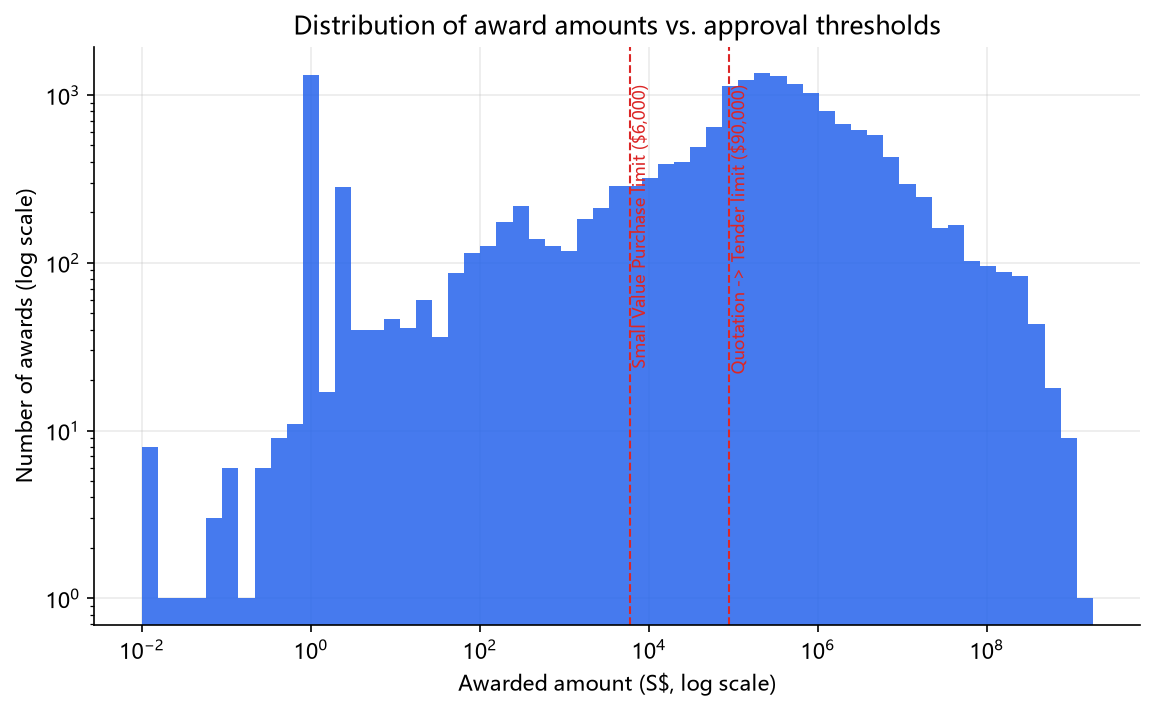

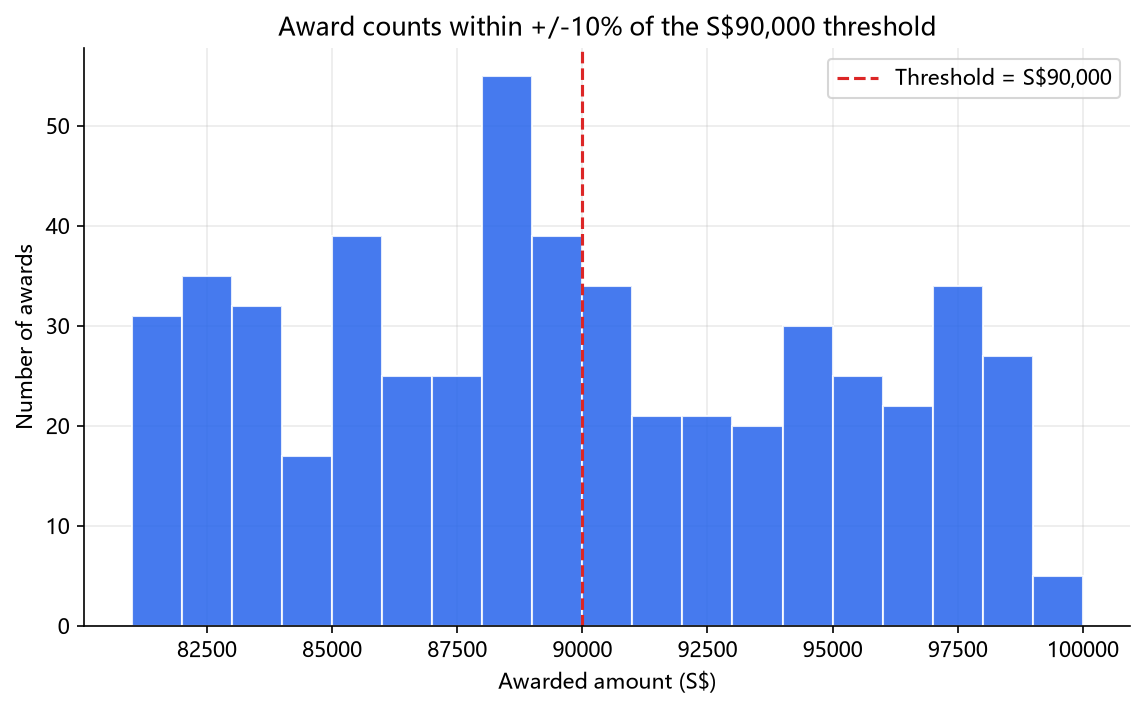

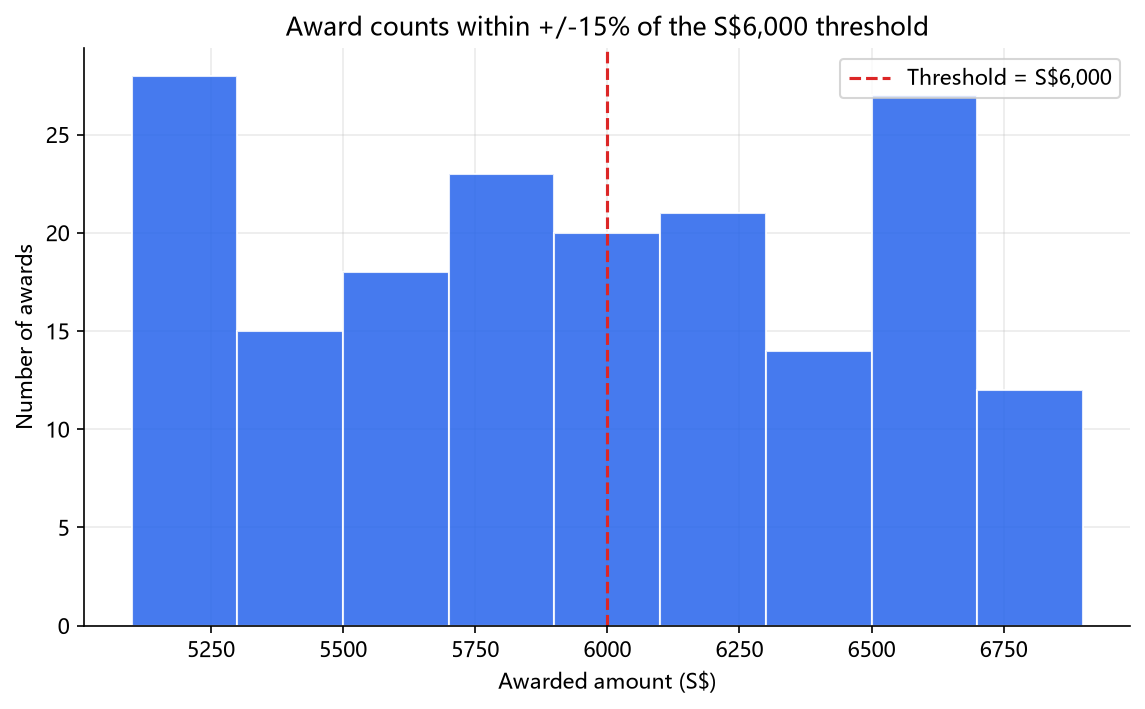

In [6]:
display(Image('../outputs/figures/amount_distribution.png'))
display(Image('../outputs/figures/threshold_zoom_90000.png'))
display(Image('../outputs/figures/threshold_zoom_6000.png'))

### Interpretation

- **At S$90,000**, the below:above ratio *increases* as the window tightens (1.25x at ±10%, 1.39x at ±5%, 1.61x at ±2%) — the opposite of what noise would produce (noise would flatten out, not sharpen, as the window narrows). The fine-grained histogram shows a real spike in the **S$88,000–S$89,000** band immediately before the threshold, then a drop-off just after S$90,000. This is consistent with, though not proof of, contracts being deliberately kept under the open-tender line.
- **At S$6,000**, there's no comparable pattern (ratios hover near 1, and the zoomed histogram is noisy rather than skewed) — consistent with the Small-Value-Purchase line being procedurally low-stakes enough that agencies don't appear to manage around it.
- **Limitation, stated plainly:** clustering is a *screening signal*, not evidence of wrongdoing. Genuine budget planning (e.g. negotiating a quote down to fit an approved budget cap) can also produce round numbers near a threshold. This analysis tells you *where to sample for a closer audit look* (e.g. did agencies that show this pattern also show frequent contract splitting on the same tender_no?) — it does not itself establish that any specific award was improperly structured.

## 4. Benford's law (leading-digit test)

**Scope decision:** Benford's law assumes values span several orders of magnitude and aren't artificially rounded or bounded — it is not expected to hold for small, often round-number transactions. I test at several minimum-amount floors rather than committing to one, to show how sensitive the result is to that choice.

In [7]:
for floor in [0, 1000, 6000, 10000]:
    r = benford_test(df['awarded_amt'], min_amount=floor)
    print(f"min_amount={floor:>6,}: n={r['n']:>6,}  chi2={r['chi2']:7.2f}  p={r['p_value']:.6f}")

min_amount=     0: n=17,821  chi2= 221.63  p=0.000000
min_amount= 1,000: n=14,889  chi2=  12.65  p=0.124446
min_amount= 6,000: n=14,048  chi2=  42.11  p=0.000001
min_amount=10,000: n=13,704  chi2=  31.40  p=0.000119


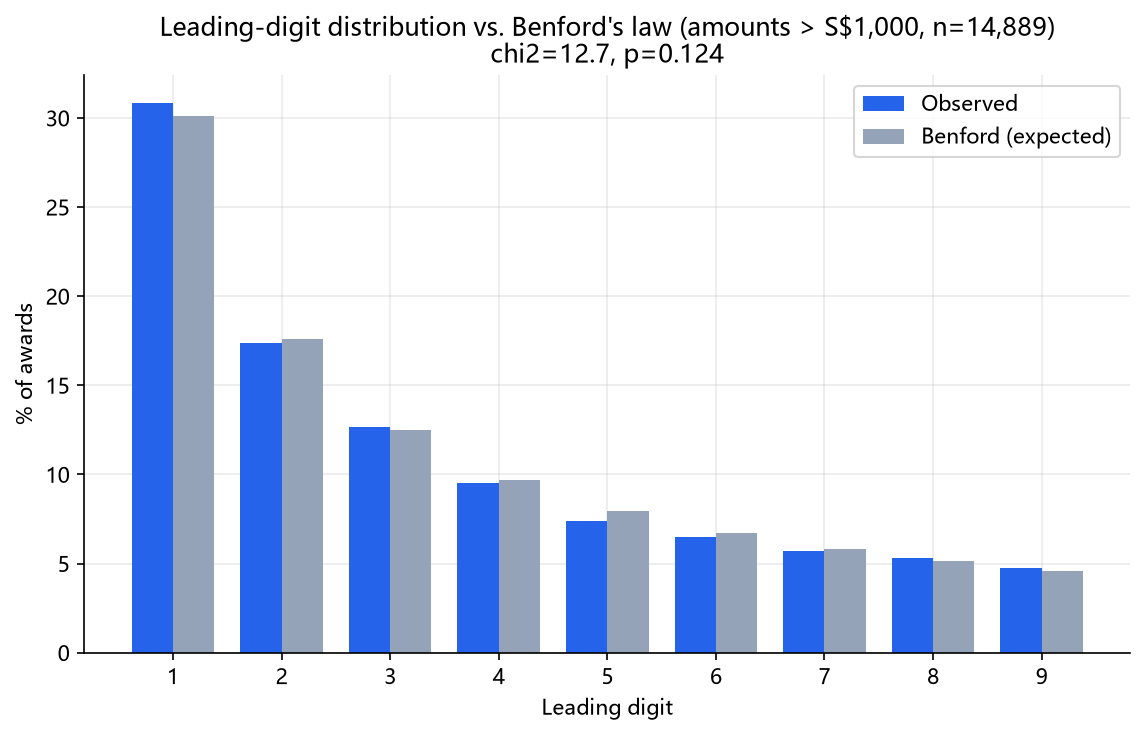

In [8]:
display(Image('../outputs/figures/benford_test.png'))

### Interpretation

- **Full dataset (no floor): fails Benford (p < 0.0001).** But this includes thousands of small line-item awards under a few thousand dollars, which are often round quoted prices — not the kind of organically-generated multiplicative data Benford's law models. A failure here mostly reflects *scope mismatch*, not fraud.
- **Excluding amounts under S$1,000: fits Benford well (p = 0.12, not significant).** This is the fairest test of the "normal" population of awards.
- **Re-imposing a floor at S$6,000 or S$10,000 (the SVP/quotation thresholds) reintroduces significant deviation (p < 0.001, p ≈ 0.0001).** I don't over-read this: at these floors we're implicitly re-including some of the threshold-clustering effect found in section 3 (a real bunching of values near round thresholds), which by itself distorts the leading-digit distribution without implying fabricated numbers. It does mean the S$1,000 floor result — not the S$6,000/S$10,000 ones — is the more trustworthy read of "does the bulk of spend look organically generated," and it says yes.
- **Limitation:** Benford deviation is, at best, a weak, aggregate screening signal. A significant chi-square result does not identify *which* transactions are anomalous, and a non-significant result does not clear every individual transaction — it only says the digit distribution isn't obviously homogeneous or manipulated in aggregate.

## 5. Supplier profile & trend

,supplier_name,total_amt,n_awards,n_agencies
0,RICH CONSTRUCTION COMPANY PTE LTD,3.539567e+09,9,4
1,KTC CIVIL ENGINEERING & CONSTRUCTION PTE LTD,2.803541e+09,19,7
2,WOH HUP PRIVATE LIMITED,2.508696e+09,6,4
3,OBAYASHI SINGAPORE PTE LTD,2.391261e+09,2,2
4,TEAMBUILD ENGINEERING & CONSTRUCTION PTE LTD,1.844377e+09,9,2
5,PENTA-OCEAN CONSTRUCTION COMPANY LIMITED,1.828634e+09,4,4
6,NEWCON BUILDERS PTE LTD,1.789420e+09,9,2
7,KAJIMA OVERSEAS ASIA SINGAPORE PTE LTD,1.735619e+09,2,2
8,BHCC CONSTRUCTION PTE LTD,1.567928e+09,6,2
9,SHANGHAI TUNNEL ENGINEERING CO SINGAPORE PTE LTD,1.426000e+09,3,2


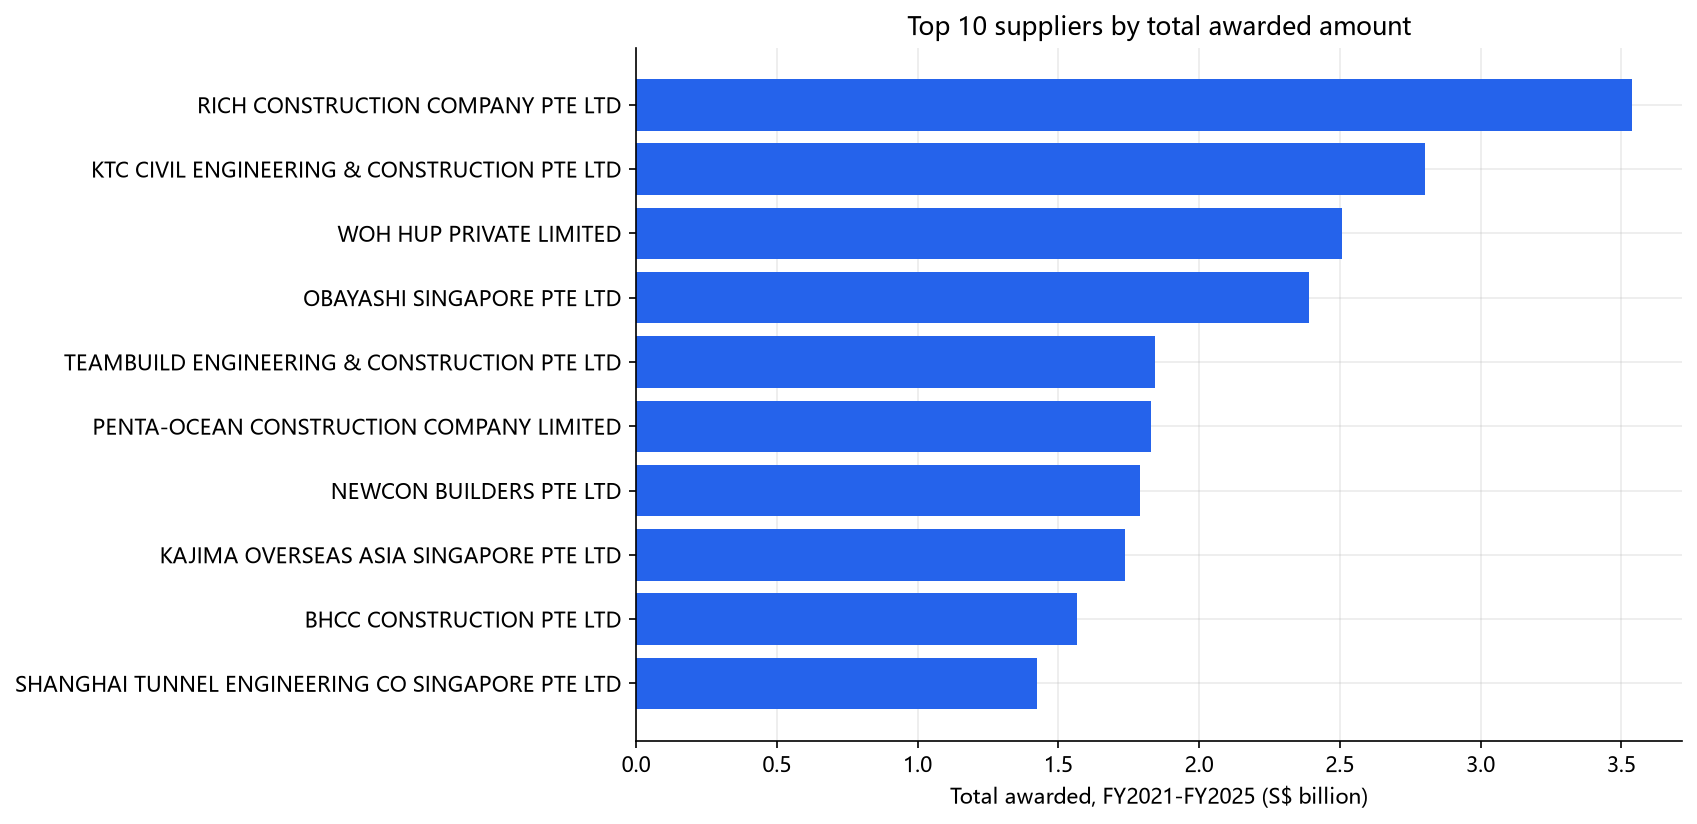

In [9]:
display(top_suppliers(df, 10))
display(Image('../outputs/figures/top_suppliers.png'))

,fiscal_year,total_amt,n_awards,n_suppliers
0,FY2021,2.418085e+10,3810,2403
1,FY2022,1.972507e+10,3333,2166
2,FY2023,2.168267e+10,3573,2284
3,FY2024,2.735110e+10,3422,2131
4,FY2025,3.088218e+10,3687,2343


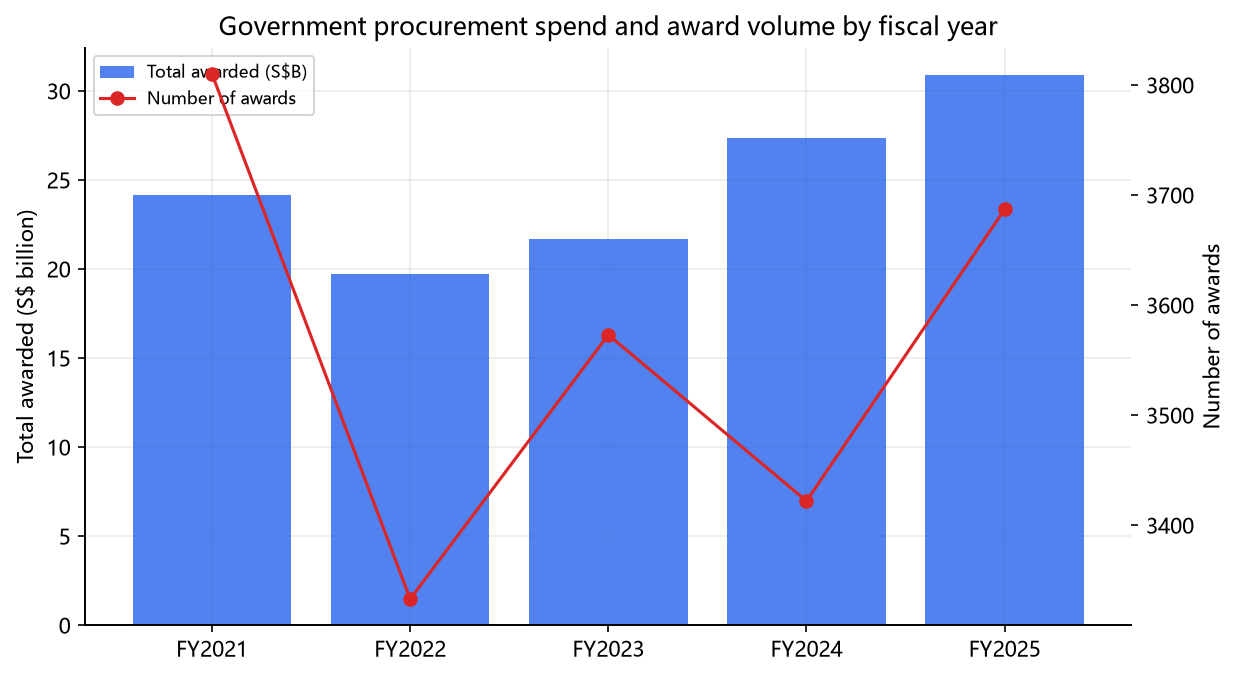

In [10]:
display(yearly_trend(df))
display(Image('../outputs/figures/yearly_trend.png'))

In [11]:
pivot = agency_year_pivot(df)
pivot['total'] = pivot.sum(axis=1)
pivot.sort_values('total', ascending=False).drop(columns='total').head(10) / 1e6  # S$ million

fiscal_year,FY2021,FY2022,FY2023,FY2024,FY2025
agency,,,,,
Land Transport Authority,10511.139286,5575.621106,6091.370731,5912.375941,6733.121960
Housing and Development Board,5659.792885,5188.081039,6655.239184,9020.817207,6846.221241
Ministry of Health-Ministry Headquarter,279.232569,1406.691195,565.154202,1918.008657,6186.562260
Ministry of Home Affairs - Ministry Headquarter 1,497.602516,1326.194696,565.596739,2690.772535,1789.065244
Public Utilities Board,1693.952645,696.144492,829.334798,1129.496532,1397.433454
Ministry of Education,548.506813,1015.040187,987.400159,1029.785318,1360.870887
National Environment Agency,981.087592,528.194311,1139.198350,654.892443,854.054344
Jurong Town Corporation,409.004661,225.386820,470.531477,1157.133132,448.707305
People's Association,188.404483,268.705777,227.544793,477.189874,257.932345


### Findings

1. The top 10 suppliers by total awarded amount are **all construction/engineering firms** (Rich Construction, KTC Civil Engineering, Woh Hup, Obayashi, Penta-Ocean, ...), each with only 2–19 awards but S$1.4B–S$3.5B in total value — consistent with a handful of large infrastructure contracts (MRT, HDB, civil works) dominating total government spend, not a sign that a few firms structurally capture government business in general.
2. Total awarded value rose from ~S$24B (FY2021) to ~S$31B (FY2025), while award *count* stayed roughly flat (~3,400–3,800/year) — spend growth is coming from bigger contracts, not more of them.
3. FY2022 had the lowest total spend (~S$19.7B) and lowest award count in the window — worth a footnote, though five fiscal years is too short a series to call this a trend rather than normal year-to-year variation (e.g. a few mega-contracts landing in adjacent fiscal years easily swings the total).
4. Agency-level spend is dominated by infrastructure/estate agencies (see pivot above) — consistent with construction firms topping the supplier list.

## Limitations

See the project [README](../README.md#局限性--limitations) for the full list. In short: this is a 5-fiscal-year rolling window (not full GeBIZ history), supplier normalization is deliberately conservative (true concentration is a lower bound, not an exact figure), and every signal here (concentration, threshold clustering, Benford deviation) is a screening flag for further audit — none of it, alone or combined, proves procurement irregularity.